## Navigo KO: Simulation vs Experimental Panels

Plots the GLI and SCN family perturbation effects across developmental lineages.

In [1]:
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from pathlib import Path
import navigo, navigo.pl
from navigo import set_seed
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## Configuration

In [2]:
DATA_DIR   = Path("/scratch/users/steorra/analysis/26_yimin/data")
OUTPUT_DIR = Path("/scratch/users/steorra/analysis/26_yimin/Navigo-release/docs/tutorials/outputs")
data_root  = DATA_DIR / 'knockout'
gli_output = data_root / 'gene_compensation' / 'gli_output'
scn_output = data_root / 'gene_compensation' / 'scn_output'
case_root  = OUTPUT_DIR / 'knockout_simulation_experimental_panels'
TABLE_DIR  = case_root / '01_tables'; FIG_DIR = case_root / '02_figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)
label_map = {'Limb#mesenchyme#trajectory':'Limb mesenchyme','Intermediate#mesoderm#trajectory':'Intermediate mesoderm',
    'Motor#neuron#trajectory':'Motor neuron','Osteoblast#trajectory':'Osteoblast',
    'Chondrocyte#trajectory':'Chondrocyte','Spinal#cord#dorsal#trajectory':'Spinal cord dorsal'}
set_seed(0)

## Step 1: Load simulation tables

In [3]:
gli_panel = pd.read_csv(gli_output / 'gli_effects_by_celltype.csv').rename(columns={'Unnamed: 0':'cell_type'})
scn_panel = pd.read_csv(scn_output / 'scn_effects_by_celltype.csv').rename(columns={'Unnamed: 0':'cell_type'})
gli_panel.to_csv(TABLE_DIR / '01_gli_effects_by_celltype.csv', index=False)
scn_panel.to_csv(TABLE_DIR / '01_scn_effects_by_celltype.csv', index=False)
print(f"GLI: {gli_panel.shape}, SCN: {scn_panel.shape}")

GLI: (8, 14), SCN: (8, 18)


## Step 2: GLI family simulated effects

<Axes: title={'center': 'GLI family effects'}, ylabel='Simulated effect'>

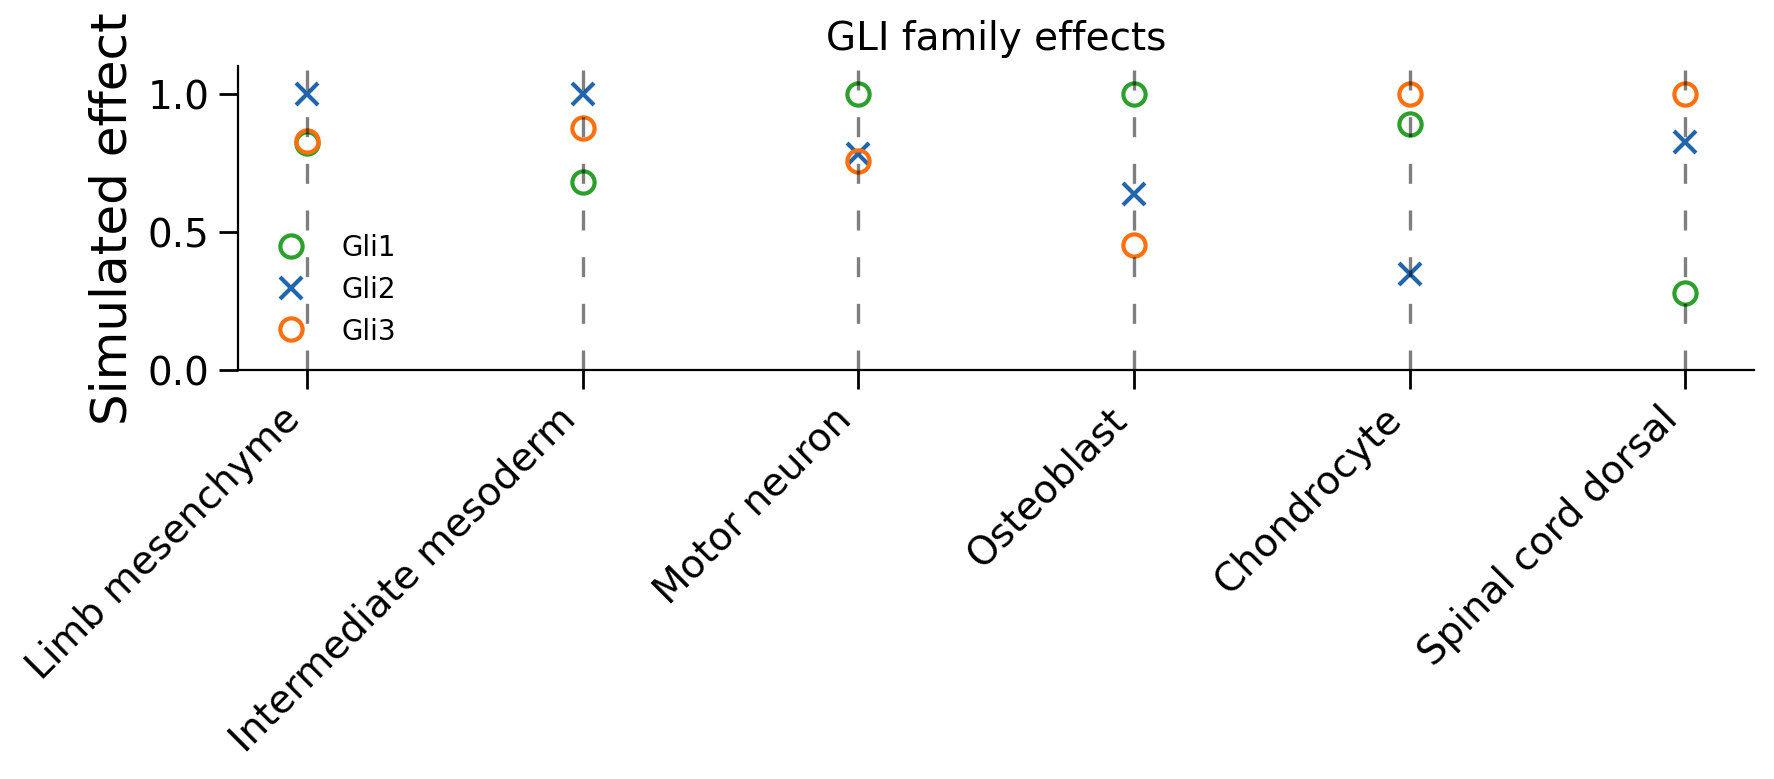

In [4]:
gli_order = ['Limb#mesenchyme#trajectory','Intermediate#mesoderm#trajectory',
    'Motor#neuron#trajectory','Osteoblast#trajectory','Chondrocyte#trajectory','Spinal#cord#dorsal#trajectory']
gli_sub = gli_panel.set_index('cell_type').loc[gli_order].reset_index()
navigo.pl.perturbation_effect_plot(
    gli_sub, x_col='cell_type', gene_columns=['Gli1_normalized','Gli2_normalized','Gli3_normalized'],
    label_map=label_map, markers=['o','x','o'], colors=['#2ca02c','#2166ac','#ff6f0e'],
    ylabel='Simulated effect', ylim=(0, 1.1), title='GLI family effects',
)

## Step 3: SCN family simulated effects

<Axes: title={'center': 'SCN family effects'}, ylabel='Simulated effect'>

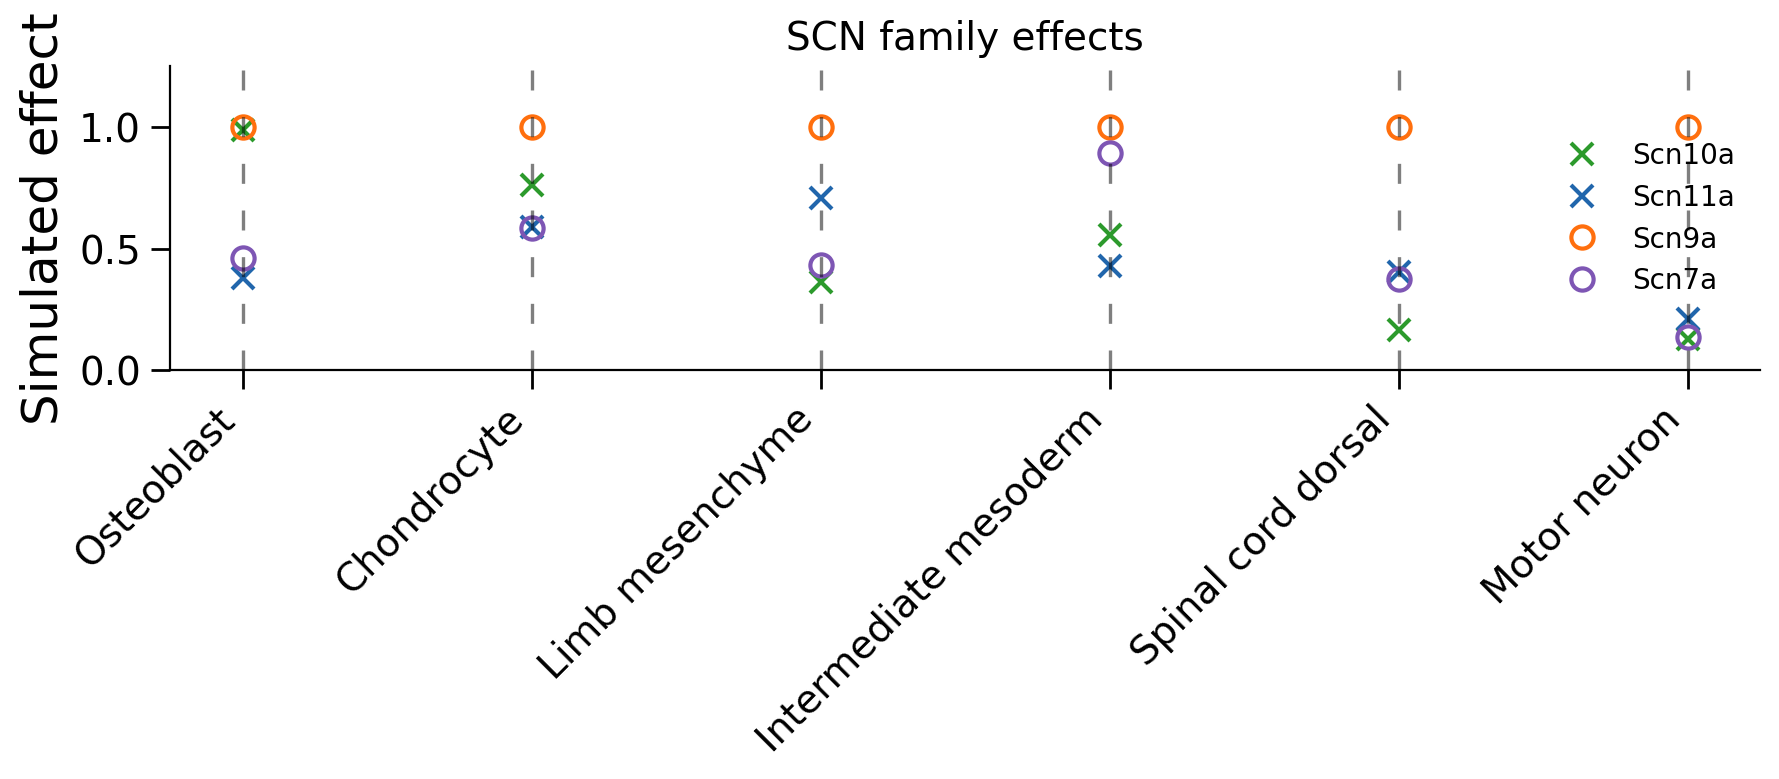

In [5]:
scn_order = ['Osteoblast#trajectory','Chondrocyte#trajectory','Limb#mesenchyme#trajectory',
    'Intermediate#mesoderm#trajectory','Spinal#cord#dorsal#trajectory','Motor#neuron#trajectory']
scn_sub = scn_panel.set_index('cell_type').loc[scn_order].reset_index()
navigo.pl.perturbation_effect_plot(
    scn_sub, x_col='cell_type', gene_columns=['Scn10a_normalized','Scn11a_normalized','Scn9a_normalized','Scn7a_normalized'],
    label_map=label_map, markers=['x','x','o','o'], colors=['#2c9a2c','#2166ac','#ff6f0e','#7e56b4'],
    ylabel='Simulated effect', ylim=(0, 1.25), title='SCN family effects',
)

## Step 4: DEG counts

<Axes: title={'center': 'GLI DEG counts'}, ylabel='DEG number'>

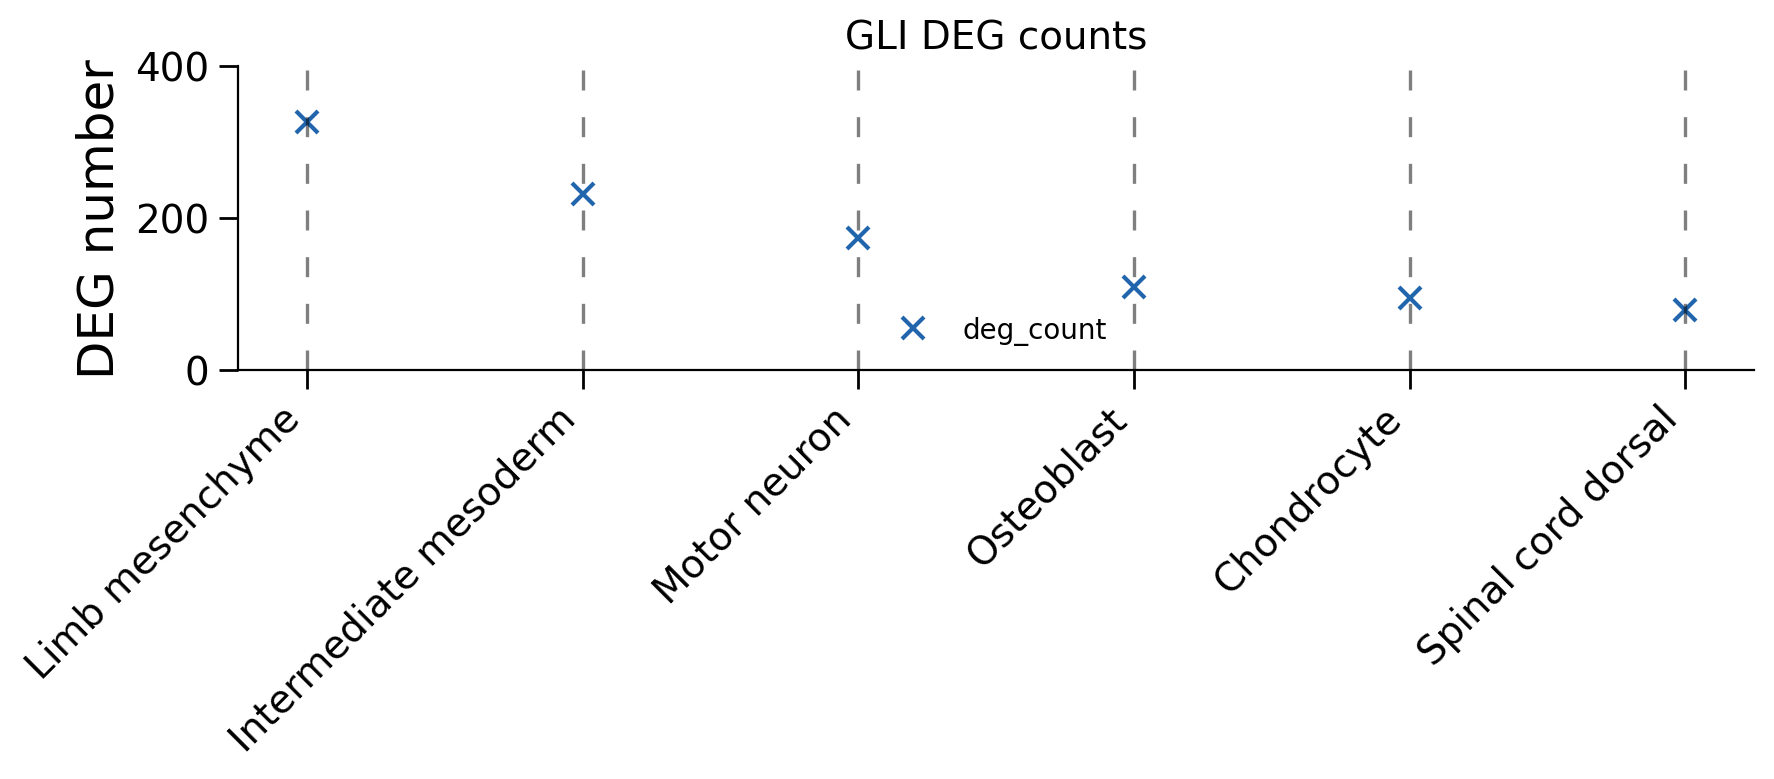

In [6]:
navigo.pl.perturbation_effect_plot(
    gli_sub, x_col='cell_type', gene_columns=['deg_count'],
    label_map=label_map, markers=['x'], colors=['#2166ac'],
    ylabel='DEG number', ylim=(0, 400), title='GLI DEG counts',
)